# optimize_arrow_check

`optimize_check_data_compare_v3.ipynb` から、**Arrow ファイルの妥当性チェック**部分だけを独立させた notebook です。

この notebook でやること:
1. `pop / info / agent` の Arrow ファイルを読む
2. 列名・型・metadata を確認する
3. 種別ごとに妥当性チェックを行う
4. 必要なら `pop.arrow` の score を再計算する
5. 簡単な可視化で中身を確認する


## 事前準備

必要なら先に以下を実行してください。

```bash
pip install polars pyarrow matplotlib
```


In [30]:
from pathlib import Path
import json
import polars as pl

pl.Config.set_tbl_rows(50)
pl.Config.set_tbl_cols(20)
pl.Config.set_fmt_str_lengths(120)

import matplotlib.pyplot as plt
from math import ceil

import pyarrow.feather as feather
import pyarrow as pa


In [31]:
# ===== ここを必要に応じて変更 =====
BASE_DIR = Path(".")
NETWORK_NAME = "ba_1000"   # "ba_1000" / "facebook" / "wiki-vote"

EXPERIMENT_DIR = BASE_DIR / f"optimize_test_{NETWORK_NAME}"
EXPERIMENT_DIR


PosixPath('optimize_test_ba_1000')

## 1. Arrow ファイルの中身を確認する

ここでは、各手法の `result/*.arrow` の中身を読み、**ファイル種別ごとに妥当性チェック**を行います。

この notebook では、次の3種類を想定します。

- `*_pop.arrow`
- `*_info.arrow`
- `*_agent.arrow`

確認できる内容:
- 列名・型
- schema metadata
- head / tail
- 行数のまとまり
- ファイル種別ごとの妥当性チェック
- `pop.arrow` の場合は `calc_score()` 相当の再計算


In [32]:
# ===== Arrow確認用の設定 =====
ARROW_METHOD = "gpr"          # "gpr" / "cmaes" / "random" / "ga"
ARROW_IDENTIFIER = "trial_best"
ARROW_KIND = "agent"            # "pop" / "info" / "agent"

ARROW_RESULT_DIR = EXPERIMENT_DIR / ARROW_METHOD / "result"
ARROW_PATH = ARROW_RESULT_DIR / f"{ARROW_IDENTIFIER}_{ARROW_KIND}.arrow"

ARROW_PATH


PosixPath('optimize_test_ba_1000/gpr/result/trial_best_agent.arrow')

In [33]:
if not ARROW_PATH.exists():
    raise FileNotFoundError(f"Arrow ファイルが見つかりません: {ARROW_PATH}")

arrow_df = pl.read_ipc(ARROW_PATH)
arrow_table = feather.read_table(ARROW_PATH)
arrow_metadata_raw = arrow_table.schema.metadata or {}

arrow_metadata = {
    (k.decode("utf-8") if isinstance(k, bytes) else str(k)):
    (v.decode("utf-8") if isinstance(v, bytes) else str(v))
    for k, v in arrow_metadata_raw.items()
}

arrow_df


num_iter,t,agent_idx,selfish
u32,u32,u32,bool
37,1,39,true
37,1,56,true
37,1,221,true
37,2,754,true
37,2,43,true
37,2,503,true
37,2,79,true
37,2,442,true
37,2,188,true


In [34]:
print("shape =", arrow_df.shape)
print("columns =", arrow_df.columns)
print("\nschema =")
for k, v in arrow_df.schema.items():
    print(f"  {k}: {v}")

print("\nmetadata =")
for k, v in arrow_metadata.items():
    print(f"  {k}: {v}")


shape = (26459, 4)
columns = ['num_iter', 't', 'agent_idx', 'selfish']

schema =
  num_iter: UInt32
  t: UInt32
  agent_idx: UInt32
  selfish: Boolean

metadata =
  agent_config: /home/e25m5333/cap-sn/v2/test_2/agent/agent-type6.toml
  app: v2
  delay_selfish: 0
  enable_inhibition: true
  iteration_count: 100
  network_config: /home/e25m5333/cap-sn/v2/test_2/network/network-ba1000.toml
  runtime: /home/e25m5333/cap-sn/v2/test_2/runtime.toml
  strategy_config: /home/e25m5333/cap-sn/optimize_test_ba_1000/gpr/strategy_trial_best.toml
  version: 0.2.1


In [35]:
print("head:")
display(arrow_df.head(10))

print("tail:")
display(arrow_df.tail(10))


head:


num_iter,t,agent_idx,selfish
u32,u32,u32,bool
37,1,39,true
37,1,56,true
37,1,221,true
37,2,754,true
37,2,43,true
37,2,503,true
37,2,79,true
37,2,442,true
37,2,188,true


tail:


num_iter,t,agent_idx,selfish
u32,u32,u32,bool
77,9,625,true
77,9,605,true
77,10,885,true
77,10,458,true
77,10,819,true
77,10,392,true
77,10,495,true
77,10,547,true
77,10,951,true


### Arrow のファイル種別を判定する

列構成から `pop / info / agent` のどれかを自動判定します。


In [36]:
def detect_arrow_type(df: pl.DataFrame) -> str:
    cols = set(df.columns)

    if {"num_iter", "t", "num_selfish"}.issubset(cols):
        return "pop"

    if {"num_iter", "t", "info_label", "num_posted", "num_received", "num_shared", "num_viewed", "num_fst_viewed"}.issubset(cols):
        return "info"

    if {"num_iter", "t", "agent_idx", "selfish"}.issubset(cols):
        return "agent"

    return "unknown"

detected_arrow_type = detect_arrow_type(arrow_df)
detected_arrow_type


'agent'

### Arrow の妥当性チェック

**共通チェック**と**種別ごとのチェック**に分けます。

- 共通: 必須列、null、`num_iter` / `t`、重複
- `pop`: `num_selfish`
- `info`: `info_label` と各カウント列
- `agent`: `agent_idx` と `selfish`


In [ ]:
def add_check(rows: list[dict], name: str, result, detail=None):
    rows.append({
        "check": name,
        "result": bool(result),
        "detail": "" if detail is None else str(detail),
    })


def build_arrow_check_df(df: pl.DataFrame, total_agents: int, metadata: dict) -> tuple[pl.DataFrame, str]:
    rows = []
    cols = set(df.columns)
    arrow_type = detect_arrow_type(df)

    # 共通
    add_check(rows, "file_type_detected", arrow_type != "unknown", arrow_type)

    common_required = {"num_iter", "t"}
    add_check(rows, "has_common_required_cols", common_required.issubset(cols), sorted(common_required - cols))

    if common_required.issubset(cols):
        null_summary = df.select([
            pl.col("num_iter").is_null().sum().alias("num_iter_null"),
            pl.col("t").is_null().sum().alias("t_null"),
        ]).to_dicts()[0]
        add_check(rows, "no_null_in_num_iter_t", all(v == 0 for v in null_summary.values()), null_summary)

        num_iter_min = df.select(pl.col("num_iter").min()).item()
        num_iter_max = df.select(pl.col("num_iter").max()).item()
        t_min = df.select(pl.col("t").min()).item()
        t_max = df.select(pl.col("t").max()).item()

        add_check(rows, "num_iter_nonnegative", num_iter_min >= 0, {"min": num_iter_min, "max": num_iter_max})
        add_check(rows, "t_nonnegative", t_min >= 0, {"min": t_min, "max": t_max})

        if "iteration_count" in metadata:
            try:
                iter_count = int(metadata["iteration_count"])
                add_check(
                    rows,
                    "num_iter_within_iteration_count",
                    num_iter_max < iter_count,
                    {"max": num_iter_max, "iteration_count": iter_count},
                )
            except Exception:
                add_check(rows, "num_iter_within_iteration_count", True, "metadata iteration_count could not be parsed")

    # 種別ごと
    if arrow_type == "pop":
        required = {"num_iter", "t", "num_selfish"}
        add_check(rows, "has_pop_required_cols", required.issubset(cols), sorted(required - cols))

        if required.issubset(cols):
            null_cnt = df.select(pl.col("num_selfish").is_null().sum()).item()
            add_check(rows, "num_selfish_no_null", null_cnt == 0, {"null_count": null_cnt})

            selfish_min = df.select(pl.col("num_selfish").min()).item()
            selfish_max = df.select(pl.col("num_selfish").max()).item()
            add_check(rows, "num_selfish_nonnegative", selfish_min >= 0, {"min": selfish_min, "max": selfish_max})
            add_check(
                rows,
                "num_selfish_within_total_agents",
                selfish_max <= total_agents,
                {"max": selfish_max, "total_agents": total_agents},
            )

            dup_rows = (
                df.group_by(["num_iter", "t"])
                  .len()
                  .filter(pl.col("len") > 1)
                  .height
            )
            add_check(rows, "no_duplicate_num_iter_t", dup_rows == 0, {"duplicate_groups": dup_rows})

    elif arrow_type == "info":
        required = {
            "num_iter", "t", "info_label",
            "num_posted", "num_received", "num_shared",
            "num_viewed", "num_fst_viewed"
        }
        add_check(rows, "has_info_required_cols", required.issubset(cols), sorted(required - cols))

        if required.issubset(cols):
            null_df = df.select([pl.col(c).is_null().sum().alias(c) for c in required]).to_dicts()[0]
            add_check(rows, "info_required_no_null", all(v == 0 for v in null_df.values()), null_df)

            count_cols = ["num_posted", "num_received", "num_shared", "num_viewed", "num_fst_viewed"]
            mins = df.select([pl.col(c).min().alias(c) for c in count_cols]).to_dicts()[0]
            add_check(rows, "info_count_cols_nonnegative", all(v >= 0 for v in mins.values()), mins)

            info_label_min = df.select(pl.col("info_label").min()).item()
            info_label_max = df.select(pl.col("info_label").max()).item()
            add_check(rows, "info_label_nonnegative", info_label_min >= 0, {"min": info_label_min, "max": info_label_max})

            dup_rows = (
                df.group_by(["num_iter", "t", "info_label"])
                  .len()
                  .filter(pl.col("len") > 1)
                  .height
            )
            add_check(rows, "no_duplicate_num_iter_t_info_label", dup_rows == 0, {"duplicate_groups": dup_rows})

            invalid_cnt = df.filter(pl.col("num_fst_viewed") > pl.col("num_viewed")).height
            add_check(rows, "num_fst_viewed_lte_num_viewed", invalid_cnt == 0, {"invalid_rows": invalid_cnt})

    elif arrow_type == "agent":
        required = {"num_iter", "t", "agent_idx", "selfish"}
        add_check(rows, "has_agent_required_cols", required.issubset(cols), sorted(required - cols))

        if required.issubset(cols):
            null_df = df.select([pl.col(c).is_null().sum().alias(c) for c in required]).to_dicts()[0]
            add_check(rows, "agent_required_no_null", all(v == 0 for v in null_df.values()), null_df)

            agent_idx_min = df.select(pl.col("agent_idx").min()).item()
            agent_idx_max = df.select(pl.col("agent_idx").max()).item()
            add_check(rows, "agent_idx_nonnegative", agent_idx_min >= 0, {"min": agent_idx_min, "max": agent_idx_max})
            add_check(
                rows,
                "agent_idx_within_total_agents",
                agent_idx_max < total_agents,
                {"max": agent_idx_max, "total_agents": total_agents},
            )

            selfish_dtype_ok = df.schema.get("selfish") == pl.Boolean
            add_check(rows, "selfish_is_boolean", selfish_dtype_ok, {"dtype": str(df.schema.get("selfish"))})

            dup_rows = (
                df.group_by(["num_iter", "t", "agent_idx"])
                  .len()
                  .filter(pl.col("len") > 1)
                  .height
            )
            add_check(rows, "no_duplicate_num_iter_t_agent_idx", dup_rows == 0, {"duplicate_groups": dup_rows})

    else:
        add_check(rows, "supported_arrow_type", False, "unknown columns")

    return pl.DataFrame(rows), arrow_type


# ===== ここから追加: TOTAL_AGENTS と metadata を安全に補完 =====

safe_arrow_metadata = globals().get("arrow_metadata", {})
if safe_arrow_metadata is None:
    safe_arrow_metadata = {}

safe_total_agents = globals().get("TOTAL_AGENTS", None)

if safe_total_agents is None:
    # metadata から取れそうなら使う
    if isinstance(safe_arrow_metadata, dict) and "agent_count" in safe_arrow_metadata:
        try:
            safe_total_agents = int(safe_arrow_metadata["agent_count"])
        except Exception:
            safe_total_agents = None

# metadata に無くても、ネットワーク名から既定値を入れる
if safe_total_agents is None:
    network_name = globals().get("NETWORK_NAME", None)
    total_agent_map = {
        "ba_1000": 1000,
        "facebook": 4039,
        "wiki-vote": 7115,
    }
    safe_total_agents = total_agent_map.get(network_name, 1000)

print(f"safe_total_agents = {safe_total_agents}")

check_df, detected_arrow_type = build_arrow_check_df(
    arrow_df,
    safe_total_agents,
    safe_arrow_metadata,
)

check_df

safe_total_agents = 1000


check,result,detail
str,bool,str
"""file_type_detected""",true,"""agent"""
"""has_common_required_cols""",true,"""[]"""
"""no_null_in_num_iter_t""",true,"""{'num_iter_null': 0, 't_null': 0}"""
"""num_iter_nonnegative""",true,"""{'min': 0, 'max': 99}"""
"""t_nonnegative""",true,"""{'min': 0, 'max': 16}"""
"""num_iter_within_iteration_count""",true,"""{'max': 99, 'iteration_count': 100}"""
"""has_agent_required_cols""",true,"""[]"""
"""agent_required_no_null""",true,"""{'num_iter': 0, 'agent_idx': 0, 'selfish': 0, 't': 0}"""
"""agent_idx_nonnegative""",true,"""{'min': 0, 'max': 999}"""


In [38]:
# 追加のまとまり確認
if detected_arrow_type == "pop":
    group_summary_df = (
        arrow_df.group_by("num_iter")
        .agg([
            pl.len().alias("rows"),
            pl.col("t").min().alias("t_min"),
            pl.col("t").max().alias("t_max"),
            pl.col("num_selfish").min().alias("num_selfish_min"),
            pl.col("num_selfish").max().alias("num_selfish_max"),
        ])
        .sort("num_iter")
    )
    display(group_summary_df)

elif detected_arrow_type == "info":
    group_summary_df = (
        arrow_df.group_by("num_iter")
        .agg([
            pl.len().alias("rows"),
            pl.col("t").min().alias("t_min"),
            pl.col("t").max().alias("t_max"),
            pl.col("info_label").n_unique().alias("n_info_labels"),
        ])
        .sort("num_iter")
    )
    display(group_summary_df)

elif detected_arrow_type == "agent":
    group_summary_df = (
        arrow_df.group_by("num_iter")
        .agg([
            pl.len().alias("rows"),
            pl.col("t").min().alias("t_min"),
            pl.col("t").max().alias("t_max"),
            pl.col("agent_idx").n_unique().alias("n_agent_idx"),
        ])
        .sort("num_iter")
    )
    display(group_summary_df)


num_iter,rows,t_min,t_max,n_agent_idx
u32,u32,u32,u32,u32
0,257,1,6,257
1,251,1,9,251
2,270,1,7,270
3,240,1,8,240
4,232,1,9,232
5,255,1,8,255
6,251,1,7,251
7,224,0,7,224
8,339,1,16,339


In [39]:
def calc_score_from_pop_arrow(df: pl.DataFrame, total_agents: int = 1000) -> float:
    if not {"num_iter", "t", "num_selfish"}.issubset(set(df.columns)):
        raise ValueError("pop.arrow 用の列が揃っていません。")

    final_rows = (
        df.group_by("num_iter")
          .agg(pl.all().sort_by("t").last())
    )
    avg_selfish = final_rows["num_selfish"].mean()
    return float(avg_selfish) / total_agents


safe_total_agents_local = globals().get("safe_total_agents", None)

if safe_total_agents_local is None:
    safe_total_agents_local = globals().get("TOTAL_AGENTS", None)

if safe_total_agents_local is None:
    safe_total_agents_local = 1000


if detected_arrow_type == "pop":
    arrow_score = calc_score_from_pop_arrow(arrow_df, safe_total_agents_local)
    print("score from pop.arrow =", arrow_score)
else:
    print("このファイル種別では score 再計算は行いません。")

このファイル種別では score 再計算は行いません。


### 簡単な可視化

`pop.arrow` なら `num_selfish` の時間変化、  
`info.arrow` なら `num_viewed`、  
`agent.arrow` なら `row数` の増え方を最初のいくつかの `num_iter` で見ます。


In [40]:
if "num_iter" in arrow_df.columns:
    sample_iters = (
        arrow_df.select("num_iter")
        .unique()
        .sort("num_iter")
        .head(5)
        .get_column("num_iter")
        .to_list()
    )
    print("sample num_iter =", sample_iters)
else:
    sample_iters = []
    print("num_iter 列が無いためスキップします。")


sample num_iter = [0, 1, 2, 3, 4]


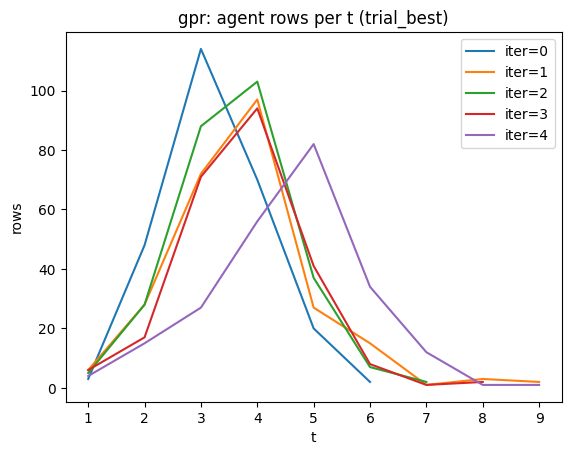

In [41]:
if sample_iters and detected_arrow_type == "pop":
    plt.figure(figsize=(9, 5))
    for it in sample_iters:
        temp = arrow_df.filter(pl.col("num_iter") == it).sort("t")
        plt.plot(temp["t"].to_list(), temp["num_selfish"].to_list(), label=f"iter={it}")
    plt.title(f"{ARROW_METHOD}: num_selfish over t ({ARROW_IDENTIFIER})")
    plt.xlabel("t")
    plt.ylabel("num_selfish")
    plt.legend()
    plt.show()

elif sample_iters and detected_arrow_type == "info":
    plt.figure(figsize=(9, 5))
    for it in sample_iters:
        temp = (
            arrow_df.filter((pl.col("num_iter") == it) & (pl.col("info_label") == 0))
                    .sort("t")
        )
        plt.plot(temp["t"].to_list(), temp["num_viewed"].to_list(), label=f"iter={it}")
    plt.title(f"{ARROW_METHOD}: num_viewed over t for info_label=0 ({ARROW_IDENTIFIER})")
    plt.xlabel("t")
    plt.ylabel("num_viewed")
    plt.legend()
    plt.show()

elif sample_iters and detected_arrow_type == "agent":
    row_curve = []
    for it in sample_iters:
        temp = (
            arrow_df.filter(pl.col("num_iter") == it)
                    .group_by("t")
                    .len()
                    .sort("t")
        )
        plt.plot(temp["t"].to_list(), temp["len"].to_list(), label=f"iter={it}")
    plt.title(f"{ARROW_METHOD}: agent rows per t ({ARROW_IDENTIFIER})")
    plt.xlabel("t")
    plt.ylabel("rows")
    plt.legend()
    plt.show()


## 9. 使い方メモ（Arrow 妥当性チェック修正版）

### まず切り替える場所
```python
ARROW_METHOD = "gpr"
ARROW_IDENTIFIER = "trial_best"
ARROW_KIND = "pop"   # "pop" / "info" / "agent"
```

### 何を見ればよいか
- `check_df` がすべて `true` か
- `group_summary_df` が不自然でないか
- `pop.arrow` の場合は `score from pop.arrow` が summary の `best_score` と大きくズレていないか
- 下のグラフで時系列の変化が不自然でないか
